In [1]:
# imports
import cmlreaders as cml
import numpy as np
import matplotlib.pyplot as plt
import os
# from ptsa_plot.ptsa_plot.topo import topoplot
import pandas as pd
from scipy.stats import ttest_rel
from scipy.stats import ttest_ind
from mne.stats import bonferroni_correction
from mne.stats import fdr_correction
import os
import cmldask.CMLDask as da
import cmldask
from dask.distributed import wait, as_completed, progress
from functools import partial
from erp import ERPGenerator

In [3]:
df = cml.get_data_index()
subjects = ["LTP606"]  # or however you collect them
gen = ERPGenerator(subjects, "ValueCourier",
                   dask_args={'job_name': "zrentala_workshop4",
                              'memory_per_job': "16GB",
                              'max_n_jobs': 25,
                              'log_directory': './results/cluster_logs'},
                   create_client=True)

trange = (-800, 1600)
brange = (-250, -50)

gen.compute_subject(
    df,
    subject=subjects[0],
    trange=trange,
    brange=brange,
    channels="A1",   # regex example; use 'all' or list like ['LA1','LA2']
    sample_rate=2048,
    freq_band=None,                  # no filtering
    hilbert_power=False
)

# 1) Broadband ERP, Fz-like contacts only (regex)
# gen.compute_all_subjects(
#     df,
#     trange=trange,
#     brange=brange,
#     channels="Fz",   # regex example; use 'all' or list like ['LA1','LA2']
#     sample_rate=500,
#     freq_band=None,                  # no filtering
#     hilbert_power=False
# )

# 2) Theta band power (4–8 Hz) over all channels
# gen.compute_all_subjects(
#     df,
#     trange=trange,
#     brange=brange,
#     channels='all',
#     sample_rate=500,
#     freq_band=(4, 8),
#     hilbert_power=True               # -> ERBP (envelope power)
# )



Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.107:33320` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser
4916
Opening raw data file /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0_clean_raw.fif...


/usr/global/miniconda/py310_23.1.0-1/envs/workshop/lib/python3.7/site-packages/distributed/node.py:161: UserWarning: Port 51618 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33320 instead
  f"Port {expected} is already in use.\n"


    Range : 0 ... 4190207 =      0.000 ...  2046.000 secs
Ready.
Opening raw data file /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0_clean_raw-1.fif...
    Range : 4190208 ... 8380415 =   2046.000 ...  4092.000 secs
Ready.
Opening raw data file /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0_clean_raw-2.fif...
    Range : 8380416 ... 10821631 =   4092.000 ...  5284.000 secs
Ready.
Reading 0 ... 10821631  =      0.000 ...  5284.000 secs...
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 75 events and 4916 original time points ...
0 bad epochs dropped
4916
['A1' 'A2' 'A3' 'A4' 'A5' 'A6' 'A7' 'A8' 'A9' 'A10' 'A11' 'A12' 'A13'
 'A14' 'A15' 'A16' 'A17' 'A18' 'A19' 'A20' 'A21' 'A22' 'A23' 'A24' 'A25'
 'A26' 'A27' 'A28' 'A29' 'A30' 'A31' 'A32' 'B1' 'B2' 'B3' 'B4' 'B5' 'B6'
 'B7' 'B8

saved → results/erp_group.pkl
✅ saved group with 1 subjects → results/erp_group.pkl


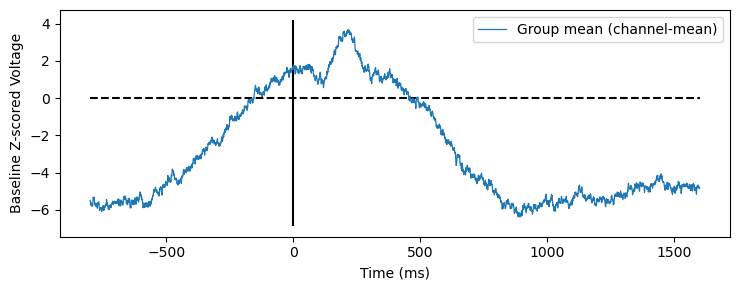

In [6]:
# build a group array and plot channel-mean
group = gen.load_group(subjects=["LTP606"], indir="results", fname_prefix="erp_subject_")
if group is not None:
    ERPGenerator.plot(group.mean(dim='subject'), trange, label="Group mean (channel-mean)")
